In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_rows", None)   # 모든 컬럼
pd.set_option("display.width", None)         # 줄바꿈 방지
pd.set_option("display.max_colwidth", None)  # 컬럼 내용 전체

BASE_DIR = Path().resolve().parent
DATA_DIR = BASE_DIR / "data" / "processed"
ANAL_DIR = DATA_DIR/"analysis_data.csv"
STAT_DIR = DATA_DIR / "stats_result.csv"
CORR_DIR = DATA_DIR / "correlation_result.csv"

anal_df = pd.read_csv(ANAL_DIR)
stat_df = pd.read_csv(STAT_DIR)
corr = pd.read_csv(CORR_DIR)


In [4]:
anal_df = anal_df[anal_df["speed"] == "slow"].reset_index(drop=True)

# for g, d in anal_df.groupby("group"):
#     display(g)
#     display(d.reset_index(drop=True))
    
    
acld = anal_df[anal_df["group"] == "ACLD"]["subject_id"].str.extract(r"(\d+)").astype(int)[0]
aclr = anal_df[anal_df["group"] == "ACLR"]["subject_id"].str.extract(r"(\d+)").astype(int)[0]

missing_in_acld = sorted(set(aclr) - set(acld))
missing_in_aclr = sorted(set(acld) - set(aclr))

missing_in_acld, missing_in_aclr

([], [])

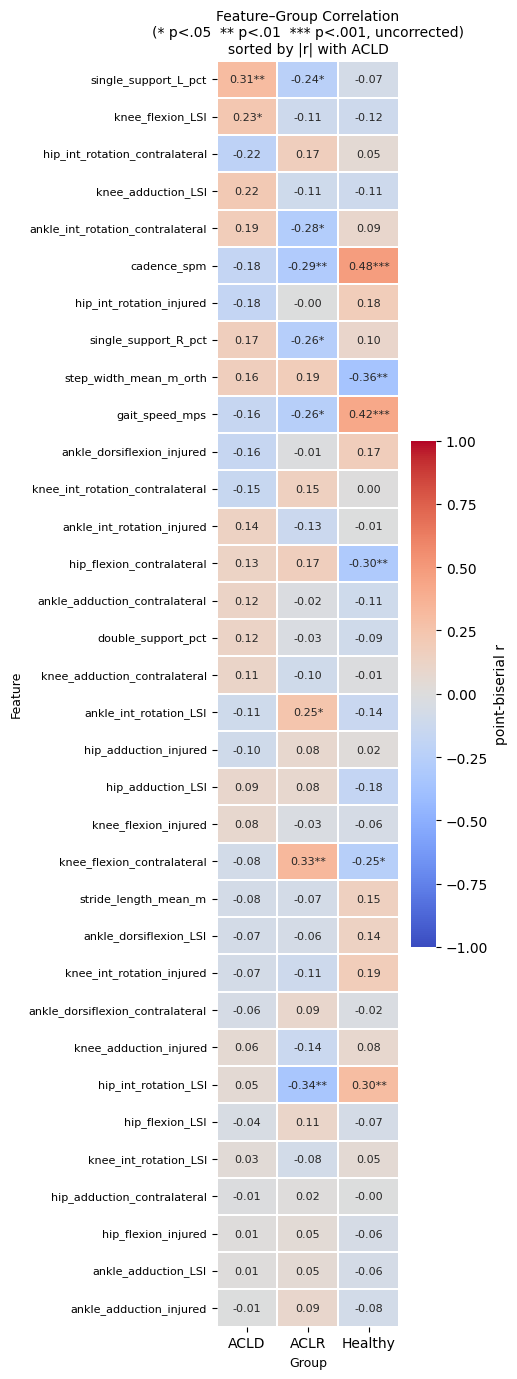

,feature,r_is_ACLD,p_is_ACLD,sig_is_ACLD,r_is_ACLR,p_is_ACLR,sig_is_ACLR,r_is_Healthy,p_is_Healthy,sig_is_Healthy,...,r_abs_is_ACLD,rank_is_ACLD,p_fdr_is_ACLR,sig_fdr_is_ACLR,r_abs_is_ACLR,rank_is_ACLR,p_fdr_is_Healthy,sig_fdr_is_Healthy,r_abs_is_Healthy,rank_is_Healthy
32,single_support_L_pct,0.3072,0.0059,**,-0.2368,0.0357,*,-0.0718,0.5294,ns,...,0.3072,1,0.1517,ns,0.2368,8,0.8079,ns,0.0718,22
21,knee_flexion_LSI,0.2280,0.0433,*,-0.1146,0.3146,ns,-0.1156,0.3103,ns,...,0.2280,2,0.6500,ns,0.1146,15,0.7338,ns,0.1156,14
11,hip_int_rotation_contralateral,-0.2181,0.0535,ns,0.1696,0.1351,ns,0.0494,0.6653,ns,...,0.2181,3,0.4445,ns,0.1696,10,0.8079,ns,0.0494,28
22,knee_adduction_LSI,0.2170,0.0548,ns,-0.1082,0.3425,ns,-0.1109,0.3305,ns,...,0.2170,4,0.6500,ns,0.1082,17,0.7338,ns,0.1109,15
17,ankle_int_rotation_contralateral,0.1854,0.1019,ns,-0.2759,0.0139,*,0.0923,0.4187,ns,...,0.1854,5,0.1182,ns,0.2759,4,0.7493,ns,0.0923,19
28,cadence_spm,-0.1796,0.1132,ns,-0.2905,0.0094,**,0.4795,0.0000,***,...,0.1796,6,0.1065,ns,0.2905,3,0.0000,***,0.4795,1
2,hip_int_rotation_injured,-0.1767,0.1192,ns,-0.0023,0.9840,ns,0.1826,0.1073,ns,...,0.1767,7,0.9840,ns,0.0023,34,0.4192,ns,0.1826,8
33,single_support_R_pct,0.1700,0.1343,ns,-0.2644,0.0185,*,0.0963,0.3984,ns,...,0.1700,8,0.1258,ns,0.2644,5,0.7493,ns,0.0963,17
30,step_width_mean_m_orth,0.1647,0.1469,ns,0.1856,0.1015,ns,-0.3572,0.0012,**,...,0.1647,9,0.3834,ns,0.1856,9,0.0136,*,0.3572,3
27,gait_speed_mps,-0.1605,0.1578,ns,-0.2562,0.0227,*,0.4249,0.0001,***,...,0.1605,10,0.1286,ns,0.2562,6,0.0017,**,0.4249,2


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path().resolve().parent
CORR_DIR = BASE_DIR / "data" / "processed" / "correlation_result.csv"

corr = pd.read_csv(CORR_DIR)
corr = corr.sort_values("rank_is_ACLD")

groups = ["ACLD", "ACLR", "Healthy"]
r_cols   = [f"r_is_{g}"   for g in groups]
sig_cols = [f"sig_is_{g}" for g in groups]

r_matrix = corr[r_cols].values

# ns → 빈 문자열, 유의하면 r값 + 별표
annot = np.array([
    [f"{r:.2f}{'' if s == 'ns' else s}" for r, s in zip(row_r, row_s)]
    for row_r, row_s in zip(r_matrix, corr[sig_cols].values)
])

n_feat = len(corr)
fig, ax = plt.subplots(figsize=(5, n_feat * 0.35 + 2))

sns.heatmap(
    r_matrix,
    annot=annot,
    fmt="",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor="white",
    xticklabels=groups,
    yticklabels=corr["feature"].values,
    annot_kws={"size": 8},
    ax=ax,
    cbar_kws={"label": "point-biserial r", "shrink": 0.4},
)
ax.set_title(
    "Feature–Group Correlation\n(* p<.05  ** p<.01  *** p<.001, uncorrected)\nsorted by |r| with ACLD",
    fontsize=10
)
ax.set_xlabel("Group", fontsize=9)
ax.set_ylabel("Feature", fontsize=9)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

corr
